## In this Notebook I run the motor using either the local functions and the explicit methods or using the libHdrive17.

In [1]:
import socket
import time
import struct
import threading
import numpy as np
from matplotlib.pyplot import *

def connect_drive():
    s_send = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s_send.connect(('192.168.1.102', 1000))
    return s_send
    

def disconnect_drive(s):
    s.shutdown(1)
    
def servoOff(s):
        # "Unpower the drive, the axis can move freely"
        str_command=b'"<control pos=\"0\" speed=\"400\" torque=\"600\" mode=\"0\" acc=\"10000\" decc=\"10000\" />"'
        s.sendall(str_command)
    
def get_motor_output():
    s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    with s: #socket.socket(socket.AF_INET, socket.SOCK_DGRAM) as s:
        s.bind(('', 1001))
        data, addr = s.recvfrom(82)
        position=int(data[18:28])
        speed=int(data[37:45])
        torque=int(data[55:63])
        t=int(data[71:81])
        return t,position,speed,torque
    
    

#http://192.168.1.102/#

# Connection to the Drive and read output

In [3]:
# Connect to motor
sdrive=connect_drive()
t,position,speed,torque=get_motor_output()
print('position',(position/10))
print('speed',speed)
print('torque',torque)
print('time',t)

position 177.8
speed 0
torque 0
time 30066959


In [4]:
speed=10
sdrive.rotate(30)
time.sleep(1)
servoOff(sdrive)

AttributeError: 'socket' object has no attribute 'rotate'

# Oscillation speed control - mode=\"130\"

In [13]:
theta_scale=10
dtheta=20
f=0.5 #Hz
timeScale=1e9
degpsTOrpm=1/6

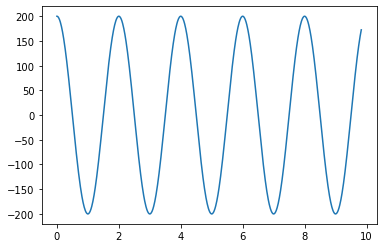

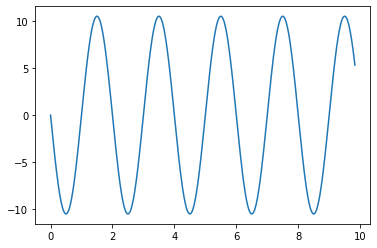

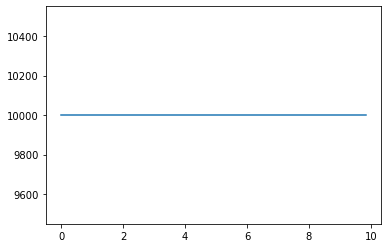

In [14]:
sdrive=connect_drive()


t_start=time.time_ns()
target_pos=[]
target_time=[]
target_speed=[]
target_acc=[]
# str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"200\" mode=\"129\" acc=\"1000\" decc=\"1000\" />"'%pos_motor
# s.sendall(str_command)

for i in range(1,800):
    current_time=time.time_ns()
    t=(current_time-t_start)/timeScale
    pos=dtheta*np.cos(2*np.pi*f*t)
    speed=-dtheta*2*np.pi*f*np.sin(2*np.pi*f*t)
    acc=-dtheta*(2*np.pi*f)**2*np.cos(2*np.pi*f*t)
    
    pos_motor=pos*theta_scale
    speed_motor=(speed*degpsTOrpm)
    acc_motor=10000
    dec_motor=acc_motor
    
    target_pos.append(pos_motor)
    target_speed.append(speed_motor)
    target_acc.append(acc_motor)
    target_time.append(t)
    
    str_command=b'"<control pos=\"%i\" speed=\"%i\" torque=\"600\" mode=\"130\" acc=\"%i\" decc=\"%i\" />"'%(pos_motor,speed_motor,acc_motor,dec_motor)
    sdrive.sendall(str_command) 
    time.sleep(0.01)
    
target_time=np.array(target_time)
target_pos=np.array(target_pos)
target_speed=np.array(target_speed)
target_acc=np.array(target_acc)

str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"400\" mode=\"129\" acc=\"10000\" decc=\"10000\" />"'
sdrive.sendall(str_command) 
time.sleep(0.0001)
    
servoOff()


# Oscillation position control - mode=\"129\"

In [15]:
theta_scale=10
dtheta=20
f=0.5 #Hz
timeScale=1e9
degpsTOrpm=1/6

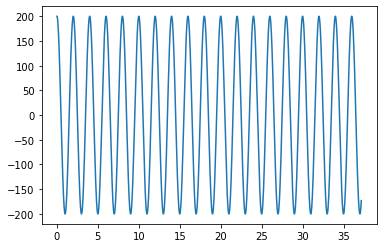

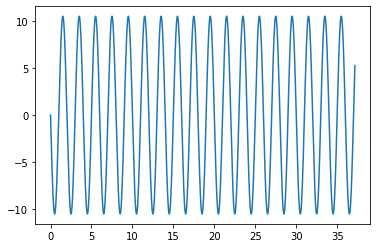

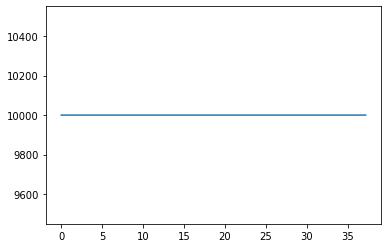

In [16]:
sdrive=connect_drive()


t_start=time.time_ns()
target_pos=[]
target_time=[]
target_speed=[]
target_acc=[]
# str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"200\" mode=\"129\" acc=\"1000\" decc=\"1000\" />"'%pos_motor
# s.sendall(str_command)

for i in range(1,3000):
    current_time=time.time_ns()
    t=(current_time-t_start)/timeScale
    pos=dtheta*np.cos(2*np.pi*f*t)
    speed=-dtheta*2*np.pi*f*np.sin(2*np.pi*f*t)
    acc=-dtheta*(2*np.pi*f)**2*np.cos(2*np.pi*f*t)
    
    pos_motor=pos*theta_scale
    speed_motor=(speed*degpsTOrpm)
    acc_motor=10000
    dec_motor=acc_motor
    
    target_pos.append(pos_motor)
    target_speed.append(speed_motor)
    target_acc.append(acc_motor)
    target_time.append(t)
    
    str_command=b'"<control pos=\"%i\" speed=\"%i\" torque=\"600\" mode=\"129\" acc=\"%i\" decc=\"%i\" />"'%(pos_motor,speed_motor,acc_motor,dec_motor)
    sdrive.sendall(str_command) 
    time.sleep(0.01)
    
target_time=np.array(target_time)
target_pos=np.array(target_pos)
target_speed=np.array(target_speed)
target_acc=np.array(target_acc)

str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"400\" mode=\"129\" acc=\"10000\" decc=\"10000\" />"'
sdrive.sendall(str_command) 
time.sleep(0.0001)
    
servoOff()


# Oscillation stepper control - mode=\"134\"

In [17]:
theta_scale=10
gearRatio=1
dtheta=30*gearRatio
f=0.5 #Hz
timeScale=1e9
degpsTOrpm=1/6

In [18]:
sdrive=connect_drive()

target_pos=[]
act_pos=[]
target_time=[]
act_time=[]
target_speed=[]
act_speed=[]
target_acc=[]
# str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"200\" mode=\"129\" acc=\"1000\" decc=\"1000\" />"'%pos_motor
# s.sendall(str_command)

str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"400\" mode=\"129\" acc=\"10000\" decc=\"10000\" />"'
sdrive.sendall(str_command) 
time.sleep(0.0001)



t_start=time.time_ns()
t0,position,speed,torque=get_motor_output()

for i in range(1,1000):
    current_time=time.time_ns()
    t,position,speed,torque=get_motor_output()
    
    act_time.append(t-t0)
    act_pos.append(position)
    act_speed.append(speed)
    
    t=(current_time-t_start)/timeScale
    pos=dtheta*np.sin(2*np.pi*f*t)
    speed=dtheta*2*np.pi*f*np.cos(2*np.pi*f*t)
    acc=-dtheta*(2*np.pi*f)**2*np.cos(2*np.pi*f*t)
    
    pos_motor=pos*theta_scale
    speed_motor=1000 #(speed*degpsTOrpm)
    acc_motor=10000
    dec_motor=acc_motor
    
    target_pos.append(pos_motor)
    target_speed.append(speed_motor)
    target_acc.append(acc_motor)
    target_time.append(t)
    str_command=b'"<control pos=\"%i\" speed=\"%i\" torque=\"600\" mode=\"134\" acc=\"%i\" decc=\"%i\" />"'%(pos_motor,speed_motor,acc_motor,dec_motor)
    sdrive.sendall(str_command) 
    time.sleep(0.001)
    
target_time=np.array(target_time)
target_pos=np.array(target_pos)/10
target_speed=np.array(target_speed)
target_acc=np.array(target_acc)
act_time=np.array(act_time)
act_pos=np.array(act_pos)
act_speed=np.array(act_speed)

servoOff(sdrive)

# str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"400\" mode=\"129\" acc=\"10000\" decc=\"10000\" />"'
# s.sendall(str_command) 
# time.sleep(0.0001)
    

# Mode 136

In [24]:
sdrive=connect_drive()


gearRatio = 1; # ratio if no speed reducer then set to 1
amplitude = 20; # amplitude in degrees
frequency = 50 # frequency in 1/s
phase = 0; # phase offset in 1/10 radiant
offset = 0; # horizontal offset in degrees
dtheta = 20
# y = Amplitude * cos( frequency * t + phase) + offset
act_pos=[]
act_time=[]
act_speed=[]



#home the motor
str_command=b'"<control pos=\"0\" speed=\"100\" torque=\"400\" mode=\"129\" acc=\"10000\" decc=\"10000\" />"'
sdrive.sendall(str_command) 
time.sleep(0.0001)
 
st = '"<control pos=\"' + str(gearRatio*amplitude*10) + '\" frequency=\"' + str(frequency) + '\" torque=\"200\" mode=\"135\" offset=\"' + str(gearRatio*offset*10) + '\" phase=\"' + str(phase) + '\" />"';
sdrive.sendall(st.encode('ascii')) # send XML command
time.sleep( 5 )

servoOff(sdrive)

In [30]:
disconnect_drive(sdrive)

# Using a class
## Restart the motor before you run those cells

In [5]:
from LibHdrive17 import *

In [6]:
mydrive=hdrive()
mydrive.connect_drive()
mydrive.home()
mydrive.get_drive_output()
mydrive.disconnect()

In [7]:
#mode 134
mydrive=hdrive()
mydrive.amplitude=45
mydrive.frequency=0.5
mydrive.connect_drive()
mydrive.mode=134
mydrive.home()
time.sleep(1)
mydrive.start() #start the rotation
time.sleep(5) #let it run for 5s
mydrive.stop()# stop the motor, home, reset
mydrive.home()
time.sleep(0.5)
mydrive.servoOff()



t=mydrive.target_time
pos=mydrive.target_pos
t134=mydrive.act_time
pos134=mydrive.act_pos



# #mode 135
# mydrive=hdrive()
# mydrive.amplitude=45
# mydrive.frequency=1
# mydrive.connect_drive()
# mydrive.mode=135
# mydrive.home()
# time.sleep(1)
# mydrive.start() #start the rotation
# time.sleep(5) #let it run for 5s
# mydrive.stop()# stop the motor, home, reset
# mydrive.home()
# time.sleep(0.5)
# mydrive.servoOff()



# t=mydrive.target_time
# pos=mydrive.target_pos
# t135=mydrive.act_time
# pos135=mydrive.act_pos



# #mode 136
# mydrive=hdrive()
# mydrive.amplitude=45
# mydrive.frequency=1
# mydrive.connect_drive()
# mydrive.mode=136
# mydrive.home()
# time.sleep(1)
# mydrive.start() #start the rotation
# time.sleep(5) #let it run for 5s
# mydrive.stop()# stop the motor, home, reset
# mydrive.home()
# time.sleep(0.5)
# mydrive.servoOff()



# t=mydrive.target_time
# pos=mydrive.target_pos
# t136=mydrive.act_time
# pos136=mydrive.act_pos

# figure()
# plot(t,pos)
# plot(t134,pos134)
# plot(t135,pos135)
# plot(t136,pos136)

start running in mode 134


# Issues with the drive

* In mode 134,135,136, the max position I read from the web GUI is always ~85% of the amplitude
* In mode 135,136 the frequency is not in Hz need to multiply by 100
* In mode 135, 20deg at 50Hz not smooth, while smooth in mode 134,136
* In mode 135,136 if I set the freq to 3.14*40 or less (*30,*20..) no motion and the drive seems to disconnect.
* the code for reading the data from the drive using the binary ticket gives weird times. Using the Hdrive tickets and the ascii string works fine. Time though is not in ms but in us.
